### ID3 - Construindo a Árvore de Decisão

Uma Árvore de Decisão é um modelo de Machine Learning utilizado para classificação. Esse modelo tenta encontrar padrões nos dados e criar um conjunto de regras lógicas na forma de um fluxograma simular a uma árvore invertida. Ele faz isso dividindo os dados continuamente até que o grupo resultante seja o mais "puro" possível (todos da mesma classe).

#### Entropia

Entropia se refere ao valor do "caos" em um conjunto de dados, ou seja, o quanto eles estão misturados. Entropia máxima significa que os dados estão totalmente misturados, enquanto entropia mínima significa que foi possível fazer uma separação completa de dados de acordo com sua classe.

Para esse Cálculo, foi utilizada a Entropia de Shannon. Sua implementação abaixo foi pensada para receber um vetor de valores(coluna label) representativos de classes que podem ser classificadas. No demais, essa função é a transcrição da fórmula de Shannon.

In [1]:
import numpy as np
from collections import Counter

In [2]:
def calculate_entropy(y):
    class_counts = Counter(y)
    total_samples = len(y)
    entropy = 0.0
    for count in class_counts.values():
        probability = count / total_samples
        if probability > 0:
            entropy -= probability * np.log2(probability)
    return entropy

#### Escolha da melhor divisão.

Tendo um grande conjunto de dados, a árvore de decisão precisa atribuir um critério para separar os dados, não necessariamente em labels finais mas de algum modo que a entropia entre os dados seja cada vez menor. A metodologia utilizada nesse caso é simplesmente testar todas as possibilidades e verificar qual delas diminui mais a entropia do dataset, essa será o critério de separação da árvore naquele ponto específico.

Abaixo, a função *calculate_information_gain* representa o novo valor de entropia após simular uma "separação" dos dados com base naquela categoria.

In [3]:
def calculate_information_gain(df, feature_name, target_name):
    total_entropy = calculate_entropy(df[target_name])
    unique_values = df[feature_name].unique()
    total_samples = len(df)
    
    weighted_entropy = 0.0
    for value in unique_values:
        subset = df[df[feature_name] == value]
        subset_weight = len(subset) / total_samples
        subset_entropy = calculate_entropy(subset[target_name])
        weighted_entropy += subset_weight * subset_entropy
        
    information_gain = total_entropy - weighted_entropy
    return information_gain

#### Motor ID3

Agora só é preciso unir as duas funções anteriormente apresentadas. A função *build_id3_tree* utiliza ambas repetidamente (de forma recursiva). Ela olha para os dados, escolhe a melhor divisão usando o Ganho de Informação, cria um "nó" de decisão, separa os dados e faz o mesmo processo para cada novo pedaço, até que tudo esteja classificado ou atinja o limite de profundidade determinado(quando informado).

O output será nossa árvore, em python e nesse projeto, ele estará representado na forma de dicionário aninhado.

In [4]:
def build_id3_tree(df, features, target_name, current_depth=0, max_depth=None):
    unique_classes = df[target_name].unique()
    
    if len(unique_classes) == 1:
        return unique_classes[0]
    
    if len(features) == 0:
        return df[target_name].mode()[0]
        
    if max_depth is not None and current_depth >= max_depth:
        return df[target_name].mode()[0]
    
    best_feature = None
    max_gain = -1
    
    for feature in features:
        gain = calculate_information_gain(df, feature, target_name)
        if gain > max_gain:
            max_gain = gain
            best_feature = feature
            
    if max_gain <= 0:
         return df[target_name].mode()[0]
            
    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]
    
    for value in df[best_feature].unique():
        subset = df[df[best_feature] == value]
        if len(subset) == 0:
            tree[best_feature][value] = df[target_name].mode()[0]
        else:
            tree[best_feature][value] = build_id3_tree(
                subset, remaining_features, target_name, current_depth + 1, max_depth
            )
            
    return tree

#### Utilizando a árvore

Com a árvore devidamente elaborada, é possível fazer a previsão de uma categoria utilizando dados reais. De modo recursivo, a função abaixo explora vários níveis do nosso dicionário aninhado até que chegue numa classificação(nó folha).

Caso a árvore não encontre folha correspondente, retorna Unknown.

In [5]:
def predict_sample(tree, sample, default_class="Unknown"):
    if not isinstance(tree, dict):
        return tree 
    
    root_node = next(iter(tree))
    feature_value = sample[root_node]
    
    if feature_value in tree[root_node]:
        return predict_sample(tree[root_node][feature_value], sample, default_class)
    else:
        return default_class

#### Salvando e Carregando Árvores

Após uma árvore ser gerada, essa é registrada para que essa possa ser utilizada numa interface para avaliação em relação a modelos MCTS.

In [6]:
import json
import os

class NumpyJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyJSONEncoder, self).default(obj)

def save_tree(tree, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True) if os.path.dirname(filename) else None
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(tree, f, cls=NumpyJSONEncoder, indent=4, ensure_ascii=False)
    print(f"💾 Modelo guardado com sucesso em: {filename}")

def load_tree(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        return json.load(f)

### ID3 - Execução e visualização

#### Execução

In [7]:
import pandas as pd

Antes de aplicarmos o algoritmo em um conjunto de dados, é preciso garantir que não haverá "Data Leakage", que é quando nosso algoritmo é treinado com dados que serão utilizados posteriormente no seu teste.

As consequências de um Data Leakage são overfitting e dados positivamente adulterados para um conjunto específico de dados. Essa equipe criou a função *custom_train_test_split*, que separa um determinado conjunto de dados em dois datasets independentes.

In [8]:
def custom_train_test_split(df, test_size=0.3):
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
    split_index = int(len(df_shuffled) * (1 - test_size))
    return df_shuffled.iloc[:split_index], df_shuffled.iloc[split_index:]

E para fazer a avaliação do modelo, uma das métricas possíveis é a accuracy, o método *calculate_accuracy* compara as previsões feitas pela Decision Tree com as previsões reais e retorna o percentual de acertos.

In [9]:
def calculate_accuracy(y_true, y_pred):
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    return correct / len(y_true) if len(y_true) > 0 else 0

Para efeitos de visualização, foi utilizado as seguinte funções:

- *_get_tree_depth*: Calcula a máxima profundeza da árvore para dimensões de plotting.
- *_get_tree_width*: Calcula o número de folhas para determinar largura da árvore.
- *_draw_node*: Desenha o nó e suas arestas.
- *_draw_tree_recursive*: Percorre a árvore desenhando os nós.
- *_plot_tree_graph*: Chama a biblioteca matplotlib e outras funções de desenho.
- *print_tree_terminal*: Faz print em terminal, caso o utilizador deseje.
- *display_tree*: Identifica o modo desejado e faz a impressão conforme o solicitado.

In [10]:
import matplotlib.pyplot as plt

def _get_tree_depth(tree):
    if not isinstance(tree, dict): return 1
    return 1 + max(_get_tree_depth(v) for v in next(iter(tree.values())).values())

def _get_tree_width(tree):
    if not isinstance(tree, dict): return 1
    return sum(_get_tree_width(v) for v in next(iter(tree.values())).values())

def _draw_node(ax, text, center, parent, edge_label):
    if "Previsão:" in text:
        bbox_props = dict(boxstyle="round,pad=0.4", fc="#d9f2d9", ec="#006600", lw=1.5)
    else:
        bbox_props = dict(boxstyle="round,pad=0.4", fc="#e6f2ff", ec="#004d99", lw=1.5)
        
    ax.text(center[0], center[1], text, ha="center", va="center", bbox=bbox_props, zorder=3, fontsize=10)
    
    if parent is not None:
        ax.plot([parent[0], center[0]], [parent[1], center[1]], color="#666666", lw=1.5, zorder=1)
        mid_x = (parent[0] + center[0]) / 2
        mid_y = (parent[1] + center[1]) / 2
        ax.text(mid_x, mid_y, edge_label, ha="center", va="center", 
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9), zorder=2, fontsize=9, color="#cc0000")

def _draw_tree_recursive(ax, tree, center, parent, edge_label, width, depth_step):
    if not isinstance(tree, dict):
        _draw_node(ax, f"Previsão:\n{tree}", center, parent, edge_label)
        return
    
    root_node = next(iter(tree))
    _draw_node(ax, root_node, center, parent, edge_label)
    
    branches = tree[root_node]
    num_branches = len(branches)
    
    child_y = center[1] - depth_step
    start_x = center[0] - width / 2
    
    current_x = start_x
    for val, subtree in branches.items():
        # Apportion width based on the size of each subtree
        child_width = _get_tree_width(subtree) * (width / _get_tree_width(tree)) if _get_tree_width(tree) > 0 else width / num_branches
        child_x = current_x + child_width / 2
        _draw_tree_recursive(ax, subtree, (child_x, child_y), center, str(val), child_width, depth_step)
        current_x += child_width

def _plot_tree_graph(tree, dataset_name="Unknown", depth_label="None"):
    # Calcula dimensões dinâmicas
    depth = _get_tree_depth(tree)
    width = _get_tree_width(tree)
    
    # Ajusta o tamanho da figura (Largura mínima 14, Altura mínima 8)
    fig_width = max(14, width * 2.0)  
    fig_height = max(8, depth * 2.5)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    
    depth_step = 1.0 / depth if depth > 1 else 0.5
    
    _draw_tree_recursive(ax, tree, center=(0.5, 1.0), parent=None, edge_label="", width=1.0, depth_step=depth_step)
    
    plt.tight_layout()
    
    # Exportar a árvore
    pdf_filename = f"tree_{dataset_name}_depth_{depth_label}.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
    print(f"🖼️ Gráfico guardado em alta resolução: {pdf_filename}")
    
    plt.show()

def print_tree_terminal(tree, indent=""):
    if not isinstance(tree, dict):
        print(f"-> Previsão: {tree}")
        return
    
    root_node = next(iter(tree))
    print(f"[{root_node}]")
    
    branches = tree[root_node]
    for i, (value, subtree) in enumerate(branches.items()):
        is_last = (i == len(branches) - 1)
        prefix = "└── " if is_last else "├── "
        print(f"{indent}{prefix}{value} ", end="")
        
        next_indent = indent + ("    " if is_last else "│   ")
        print_tree_terminal(subtree, next_indent)

def display_tree(tree, mode="terminal", dataset_name="Unknown", depth_label="None"):
    if mode in ["terminal", "both"]:
        print_tree_terminal(tree)
    
    if mode in ["plot", "both"]:
        _plot_tree_graph(tree, dataset_name, depth_label)

Com a métrica de avaliação definida e a garantia de que os dados podem ser corretamente interpretados de acordo com os padrões da análise de dados e treinamento de modelos, implementou-se o método *train_and_evaluate*. Ao ser chamado, esse método utiliza das funções anteriormente definidas para criar a árvore, separar o dataset, calcular suas métricas.

In [11]:
def train_and_evaluate(dataset_name, train_df, test_df, features, target, depths_to_test, display_mode):
    most_common = train_df[target].mode()[0]
    y_true_train = train_df[target].tolist()
    y_true_test = test_df[target].tolist()
    
    print(f"\n{'='*50}")
    print(f" INICIANDO AVALIAÇÃO - DATASET {dataset_name}")
    print(f"{'='*50}")
    
    for depth in depths_to_test:
        depth_label = depth if depth is not None else "Sem_Limite"
        print(f"\n⚙️ A treinar árvore com max_depth = {depth_label}...")
        
        tree = build_id3_tree(train_df, features, target, max_depth=depth)
        
        json_filename = f"modelo_{dataset_name}_depth_{depth_label}.json"
        save_tree(tree, json_filename)
        
        if display_mode != 'none':
            print(f"\n--- ESTRUTURA DA ÁRVORE (Profundidade: {depth_label}) ---")
            display_tree(tree, mode=display_mode, dataset_name=dataset_name, depth_label=depth_label)
            print("-" * 50)
            
        y_pred_train = [predict_sample(tree, row, most_common) for _, row in train_df.iterrows()]
        acc_train = calculate_accuracy(y_true_train, y_pred_train)
        
        y_pred_test = [predict_sample(tree, row, most_common) for _, row in test_df.iterrows()]
        acc_test = calculate_accuracy(y_true_test, y_pred_test)
        
        print(f"🎯 RESULTADOS (Max Depth: {depth_label}):")
        print(f"  -> Accuracy no Treino: {acc_train * 100:.2f}%")
        print(f"  -> Accuracy no Teste:  {acc_test * 100:.2f}%")

Embora a função *train_and_evaluate* seja o coração do modelo, ela é cega: apenas executa matemática pura e espera receber os dados perfeitamente estruturados. Para colmatar esta lacuna, foi criada a função *execute_model*. O papel desta função é servir de ponte entre o utilizador e o algoritmo. É ela que prepara o terreno: define a proporção ideal entre treino e teste para o dataset em questão, recolhe os parâmetros desejados pelo utilizador (como os limites de profundidade) e, só então, injeta este pacote de informações no motor de treino. Isto evita a poluição do código central e torna o pipeline muito mais organizado.

Mas antes, a equipa também considerou a construção de múltiplas árvores com diversas profundidades para efeitos comparativos. Então para converter uma string de texto, que será futuramente solicitada no input, em uma lista, criou-se a função *parse_depths*, para fins de padronização e evitar falhas.

In [12]:
def parse_depths(depth_str):
    """Converte uma string '2,4,None' numa lista [2, 4, None]"""
    depths = []
    for d in depth_str.split(','):
        d = d.strip()
        if d.lower() == 'none' or d == '':
            depths.append(None)
        else:
            try:
                depths.append(int(d))
            except ValueError:
                print(f"Aviso: Valor inválido ignorado -> {d}")
    return depths

In [13]:
def execute_model(dataset_name, df, features, target):
    test_size = 0.3 if dataset_name == "IRIS" else 0.2
    train_df, test_df = custom_train_test_split(df, test_size=test_size)
    
    print(f"\n📊 Distribuição dos Dados ({dataset_name}):")
    print(f"  -> Total de amostras: {len(df)}")
    print(f"  -> Treino: {len(train_df)} amostras")
    print(f"  -> Teste:  {len(test_df)} amostras\n")
    
    # INTERACTIVE QUESTIONS
    multi_response = input(f"Deseja testar múltiplas profundidades para o {dataset_name}? (s/n): ").strip().lower()
    
    if multi_response == 's':
        default_pattern = "2,4,6,8,10,14,18,24,30,40,50,None"
        depths_str = input(f"Introduza as profundidades separadas por vírgula\n(Pressione Enter para usar o padrão: {default_pattern}): ").strip()
        if not depths_str:
            depths_str = default_pattern
        depths_to_test = parse_depths(depths_str)
    else:
        depth_response = input("Introduza a profundidade única desejada (ou deixe em branco para 'None'): ").strip()
        depths_to_test = parse_depths(depth_response) if depth_response else [None]
        
    print("\nComo deseja visualizar a(s) árvore(s)?")
    print("[1] Apenas no Terminal")
    print("[2] Gráfico (Ideal para Notebooks)")
    print("[3] Ambos (Terminal e Gráfico)")
    print("[0] Não imprimir árvore")
    print_response = input("Escolha (0-3): ").strip()
    
    display_mode = 'none'
    if print_response == '1':
        display_mode = 'terminal'
    elif print_response == '2':
        display_mode = 'plot'
    elif print_response == '3':
        display_mode = 'both'
    
    # Call the main training and evaluation engine
    train_and_evaluate(dataset_name, train_df, test_df, features, target, depths_to_test, display_mode)


#### Dataset - Iris

Nos termos desse Assingment, foi disponibilizado um dataset inicial chamado "iris.csv", que possui como finalidade comprovar a boa implementação do algoritmo ID3.

Para executar a Árvore de decisão nele, duas estratégias são adotadas:
- Remover a coluna 'ID', uma vez que essa não possui valor para categorização e poderá causar ruído nas avaliações da árvore como sendo uma feature determinística.

- Fazer a discretização dos valores disponibilizados no dataset, que consiste no agrupamento dos valores númericos em categorias para que a Decision Tree consiga ser mais eficiente e não sofrer problemas como OverFitting.

A função *load_iris_data* abaixo faz ambas as coisas, e por fim, retorna o dataset modificado, uma lista com os nomes das colunas não-alvo, e a coluna alvo.

In [18]:
def load_iris_data():
    df_iris = pd.read_csv('iris.csv')
    
    if 'ID' in df_iris.columns:
        df_iris = df_iris.drop(columns=['ID'])
        
    features_iris = ['sepallength', 'sepalwidth', 'petallength', 'petalwidth']
    target_iris = 'class'

    # Lógica de discretização embutida diretamente aqui
    print("\n--- Limites de Discretização (Valores de Corte) ---")
    for col in features_iris:
        df_iris[col], bins = pd.qcut(df_iris[col], q=3, labels=['Baixo', 'Médio', 'Alto'], retbins=True, duplicates='drop')
        print(f"Feature: '{col}' | Baixo: <= {bins[1]:.2f} | Médio: <= {bins[2]:.2f} | Alto: <= {bins[3]:.2f}")
    print("---------------------------------------------------")
    
    return df_iris, features_iris, target_iris


=== A PREPARAR DADOS IRIS ===

--- Limites de Discretização (Valores de Corte) ---
Feature: 'sepallength' | Baixo: <= 5.40 | Médio: <= 6.30 | Alto: <= 7.90
Feature: 'sepalwidth' | Baixo: <= 2.90 | Médio: <= 3.20 | Alto: <= 4.40
Feature: 'petallength' | Baixo: <= 2.63 | Médio: <= 4.90 | Alto: <= 6.90
Feature: 'petalwidth' | Baixo: <= 0.87 | Médio: <= 1.60 | Alto: <= 2.50
---------------------------------------------------

📊 Distribuição dos Dados (IRIS):
  -> Total de amostras: 150
  -> Treino: 105 amostras
  -> Teste:  45 amostras




Como deseja visualizar a(s) árvore(s)?
[1] Apenas no Terminal
[2] Gráfico (Ideal para Notebooks)
[3] Ambos (Terminal e Gráfico)
[0] Não imprimir árvore

 INICIANDO AVALIAÇÃO - DATASET IRIS

⚙️ A treinar árvore com max_depth = Sem_Limite...
💾 Modelo guardado com sucesso em: modelo_IRIS_depth_Sem_Limite.json

--- ESTRUTURA DA ÁRVORE (Profundidade: Sem_Limite) ---
🖼️ Gráfico guardado em alta resolução: tree_IRIS_depth_Sem_Limite.pdf


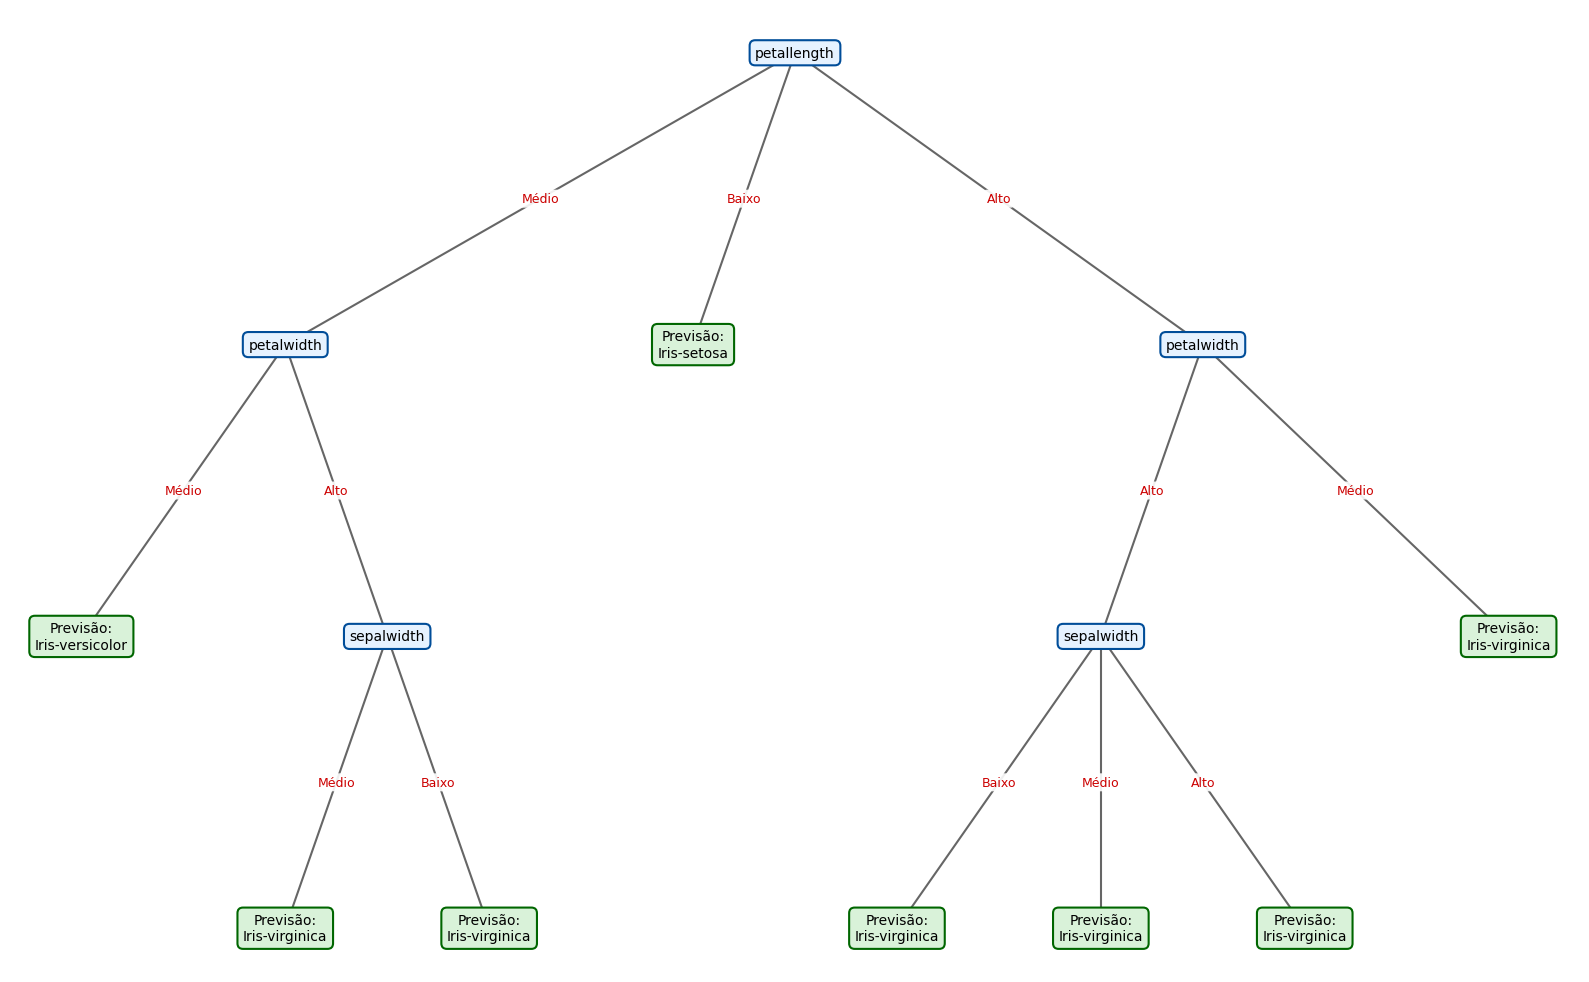

--------------------------------------------------
🎯 RESULTADOS (Max Depth: Sem_Limite):
  -> Accuracy no Treino: 97.14%
  -> Accuracy no Teste:  100.00%


In [19]:
print("\n=== A PREPARAR DADOS IRIS ===")
try:
    df_iris, features_iris, target_iris = load_iris_data()
    execute_model("IRIS", df_iris, features_iris, target_iris)
except FileNotFoundError:
    print("❌ ERRO: Ficheiro 'iris.csv' não encontrado.")

#### Dataset - Popout

Por ser um dataset não-numérico, não é necessário seu tratamento prévio, além de que já tenha sido elaborado considerando sua inserção num modelo de aprendizam computacional ID3. Logo, a função abaixo apenas carrega o dataset e retorna os valores necessários para a execução do modelo.

In [16]:
def load_popout_data():
    """Apenas carrega e devolve os dados do Popout."""
    df_popout = pd.read_csv('dataset_winners.csv')
    features_popout = [f"c_{r}_{c}" for r in range(6) for c in range(7)]
    target_popout = 'move'

    return df_popout, features_popout, target_popout

In [17]:
print("\n=== A PREPARAR DADOS POPOUT ===")
try:
    df_popout, features_popout, target_popout = load_popout_data()
    execute_model("POPOUT", df_popout, features_popout, target_popout)
except FileNotFoundError:
    print("❌ ERRO: Ficheiro 'dataset_winners.csv' não encontrado.")


=== A PREPARAR DADOS POPOUT ===

📊 Distribuição dos Dados (POPOUT):
  -> Total de amostras: 114748
  -> Treino: 91798 amostras
  -> Teste:  22950 amostras


Como deseja visualizar a(s) árvore(s)?
[1] Apenas no Terminal
[2] Gráfico (Ideal para Notebooks)
[3] Ambos (Terminal e Gráfico)
[0] Não imprimir árvore

 INICIANDO AVALIAÇÃO - DATASET POPOUT

⚙️ A treinar árvore com max_depth = Sem_Limite...
💾 Modelo guardado com sucesso em: modelo_POPOUT_depth_Sem_Limite.json
🎯 RESULTADOS (Max Depth: Sem_Limite):
  -> Accuracy no Treino: 84.69%
  -> Accuracy no Teste:  68.84%
